# **Strava Run Prediction Model**

In [25]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [26]:
sns.set_style("whitegrid")

# load cleaned data
runs = pd.read_csv("../data/runs_cleaned_data.csv")
runs["date"] = pd.to_datetime(runs["date"])

# quick data check
print(runs.shape)
runs.head()

(24, 28)


,date,Activity Name,Activity Type,distance_m,moving_time_s,elapsed_time_s,avg_speed,max_speed,elev_gain,elev_loss,...,Weather Temperature,Humidity,Wind Speed,Commute,Long Run,Competition,distance_miles,time_min,pace_min_per_mile,distance_bin
0,2025-01-24 17:24:29,Lunch Run,Run,3.31,1051.0,1160,3.157,5.020,27.2,43.6,...,NaN,NaN,NaN,False,NaN,NaN,2.056738,17.516667,8.516722,2.1
1,2025-02-01 16:26:38,Morning Run,Run,8.04,2950.0,3711,2.728,8.241,74.8,78.4,...,NaN,NaN,NaN,False,NaN,NaN,4.995823,49.166667,9.841555,5.0
2,2025-02-09 17:31:46,Lunch Run,Run,4.86,1658.0,1711,2.936,4.838,27.6,64.0,...,NaN,NaN,NaN,False,NaN,NaN,3.019863,27.633333,9.150525,3.0
3,2025-07-11 01:16:19,Evening Run,Run,3.23,1102.0,1201,2.934,4.800,20.4,18.4,...,NaN,NaN,NaN,False,NaN,NaN,2.007028,18.366667,9.151175,2.0
4,2025-08-13 11:16:22,Morning Run,Run,3.25,1180.0,1253,2.758,4.740,21.2,19.2,...,25.0,0.81,0.9,False,NaN,NaN,2.019456,19.666667,9.738597,2.0


## Feature Engineering on DataFrame

In [27]:
# get the recent period (last 8 weeks)
end_date = runs["date"].max()
start_date = end_date - pd.Timedelta(weeks=8)
recent_runs = runs[(runs["date"] >= start_date) & (runs["date"] <= end_date)]

# fastest pace for runs ~3–7 miles (5K–10K efforts)
mask = (recent_runs["distance_miles"] >= 3) & (recent_runs["distance_miles"] <= 7)
fastest_pace_5k = recent_runs[mask]["pace_min_per_mile"].min()

# average pace of all recent runs
avg_pace_recent = recent_runs["pace_min_per_mile"].mean()

# max distance in last 8 weeks
max_distance_recent = recent_runs["distance_miles"].max()

# total mileage in last 8 weeks
weekly_mileage = recent_runs.groupby(recent_runs["date"].dt.to_period("W"))["distance_miles"].sum()
total_mileage_8w = weekly_mileage.sum()

# create a feature dataframe
features = pd.DataFrame({
    "fastest_pace_5k": [fastest_pace_5k],
    "avg_pace_recent": [avg_pace_recent],
    "max_distance_recent": [max_distance_recent],
    "total_mileage_8w": [total_mileage_8w]  # updated column name
})

features

,fastest_pace_5k,avg_pace_recent,max_distance_recent,total_mileage_8w
0,7.897093,8.295965,6.238565,27.793925


In [28]:
# select base run: fastest run between 3–7 miles (includes recent 10Ks trained for)
mask = (recent_runs["distance_miles"] >= 3) & (recent_runs["distance_miles"] <= 7)
base_run = recent_runs[mask].sort_values("pace_min_per_mile").iloc[0]

D1 = base_run["distance_miles"]
T1 = base_run["time_min"]

D2 = 6.2137  # 10K in miles

# Riegel formula: T2 = T1 * (D2 / D1)^1.06
T2 = T1 * (D2 / D1) ** 1.06
predicted_pace_10k = T2 / D2

print(f"Base run: {D1:.2f} mi in {T1:.1f} min ({T1/D1:.2f} min/mi)")
print(f"Predicted 10K: {T2:.1f} min ({predicted_pace_10k:.2f} min/mi)")

Base run: 3.01 mi in 23.8 min (7.90 min/mi)
Predicted 10K: 51.3 min (8.25 min/mi)


## **_Visualize Recent Pace vs Predicted 10K_**

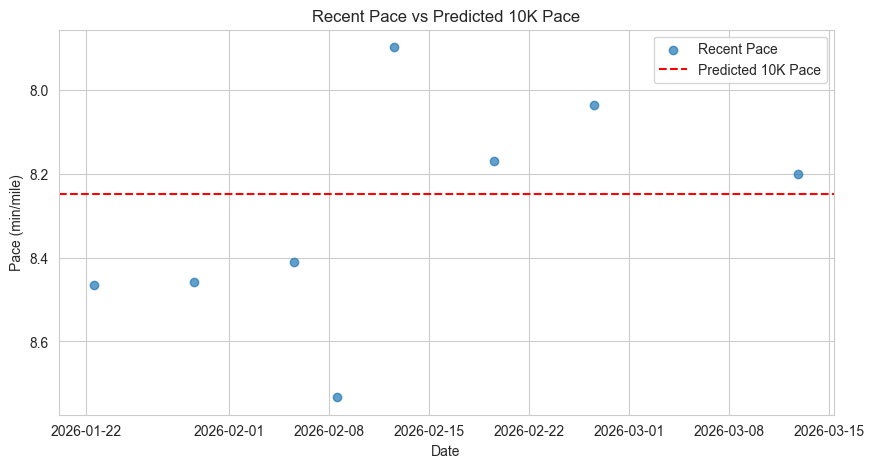

In [29]:
plt.figure(figsize=(10,5))
plt.scatter(recent_runs["date"], recent_runs["pace_min_per_mile"], alpha=0.7, label="Recent Pace")
plt.axhline(predicted_pace_10k, color='red', linestyle='--', label="Predicted 10K Pace")
plt.gca().invert_yaxis()  # faster paces on top
plt.xlabel("Date")
plt.ylabel("Pace (min/mile)")
plt.title("Recent Pace vs Predicted 10K Pace")
plt.legend()
plt.show()

## **_Machine Learning Model Prediction_**

In [30]:
# create dataset
ml_data = recent_runs.copy()

# Target: extrapolate 10K time using Riegel
D2 = 6.2137  # 10K in miles
ml_data["target_10k_time"] = ml_data["time_min"] * (D2 / ml_data["distance_miles"])**1.06

# features
ml_data["max_distance_8w"] = max_distance_recent
ml_data["total_mileage_8w"] = total_mileage_8w

features_cols = ["distance_miles", "pace_min_per_mile", "max_distance_8w", "total_mileage_8w"]
X = ml_data[features_cols]
y = ml_data["target_10k_time"]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **_Train Linear Regression Model_**

In [31]:
# init and train model
model = LinearRegression()
model.fit(X_train, y_train)

# predict on test set
y_pred = model.predict(X_test)

# evaulate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression MAE: {mae:.2f} min")
print(f"R^2 score: {r2:.2f}")

Linear Regression MAE: 0.02 min
R^2 score: 1.00


## **_Predict Next 10K Time and Pace_**

In [32]:
# use the summary features we created earlier
next_10k_features = pd.DataFrame({
    "distance_miles": [6.2137],  # 10K distance
    "pace_min_per_mile": [fastest_pace_5k],  # fastest 3–7 mi pace
    "max_distance_8w": [max_distance_recent],
    "total_mileage_8w": [total_mileage_8w]
})

predicted_10k_time = model.predict(next_10k_features)[0]
predicted_10k_pace = predicted_10k_time / 6.2137

print(f"Predicted next 10K time: {predicted_10k_time:.1f} min")
print(f"Predicted next 10K pace: {predicted_10k_pace:.2f} min/mi")

Predicted next 10K time: 48.8 min
Predicted next 10K pace: 7.86 min/mi


## **_Visualize Predictions vs Training_**

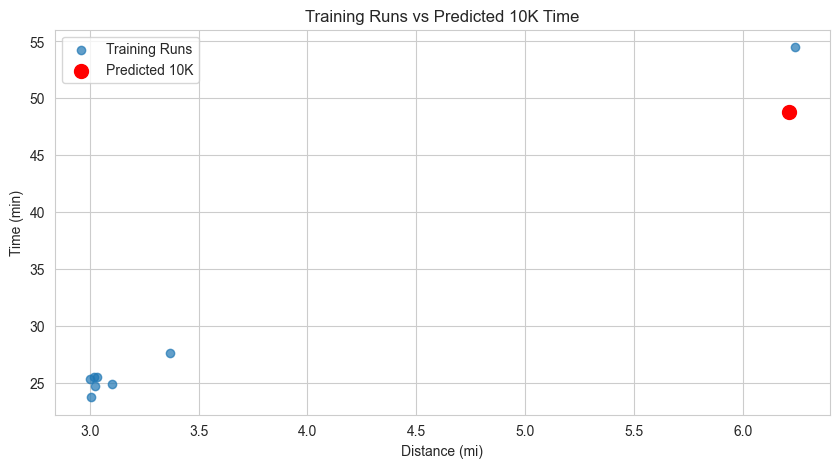

In [33]:
plt.figure(figsize=(10,5))
plt.scatter(recent_runs["distance_miles"], recent_runs["time_min"], alpha=0.7, label="Training Runs")
plt.scatter(6.2137, predicted_10k_time, color='red', s=100, label="Predicted 10K")
plt.xlabel("Distance (mi)")
plt.ylabel("Time (min)")
plt.title("Training Runs vs Predicted 10K Time")
plt.legend()
plt.show()

# **Comparing Riegel Formula Baseline Calculation vs ML Model Prediction**

## **_Bar Chart Comparison_**

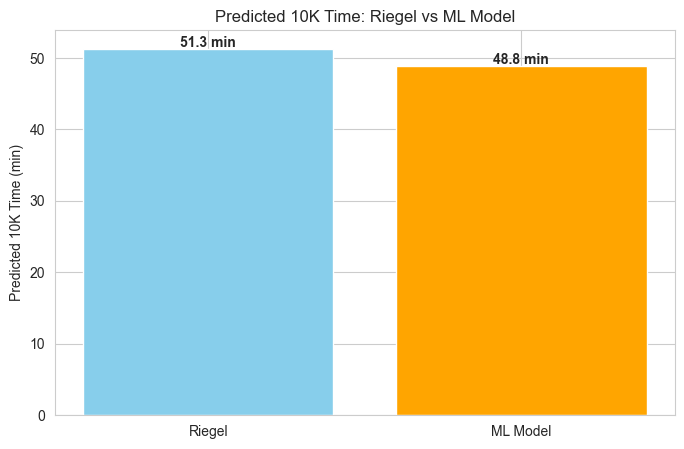

In [34]:
# preds
pred_times = [51.3, 48.8]  # Riegel, ML
labels = ["Riegel", "ML Model"]

plt.figure(figsize=(8,5))
plt.bar(labels, pred_times, color=["skyblue", "orange"])
plt.ylabel("Predicted 10K Time (min)")
plt.title("Predicted 10K Time: Riegel vs ML Model")

# annotate values
for i, v in enumerate(pred_times):
    plt.text(i, v + 0.3, f"{v:.1f} min", ha='center', fontweight='bold')

plt.show()

## **_Pace Comparison_**

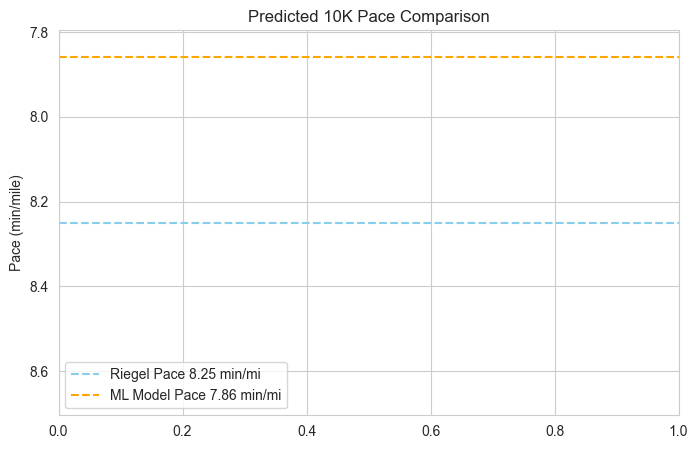

In [35]:
plt.figure(figsize=(8,5))

# riegel pace line
plt.axhline(8.25, color='skyblue', linestyle='--', label="Riegel Pace 8.25 min/mi")

# ML model pace line
plt.axhline(7.86, color='orange', linestyle='--', label="ML Model Pace 7.86 min/mi")

plt.ylabel("Pace (min/mile)")
plt.title("Predicted 10K Pace Comparison")
plt.gca().invert_yaxis()  # faster paces higher
plt.legend()
plt.show()